 TAHAP 1: PROSES UNGGAH DATASET PENELITIAN                        


Saving dataset final inflasi nilai tukar Jan2020 - Apr2026.xlsx to dataset final inflasi nilai tukar Jan2020 - Apr2026 (6).xlsx

 TAHAP 2: PREPROCESSING & TRANSFORMASI STRUKTUR RUNTUN WAKTU 
  - Total Observasi Valid Terdeteksi: 76
  - Periode Data Awal : 2020-01-01
  - Periode Data Akhir: 2026-04-01

 TAHAP 3: VISUALISASI TREN & INSPEKSI GRAFIK AWAL 


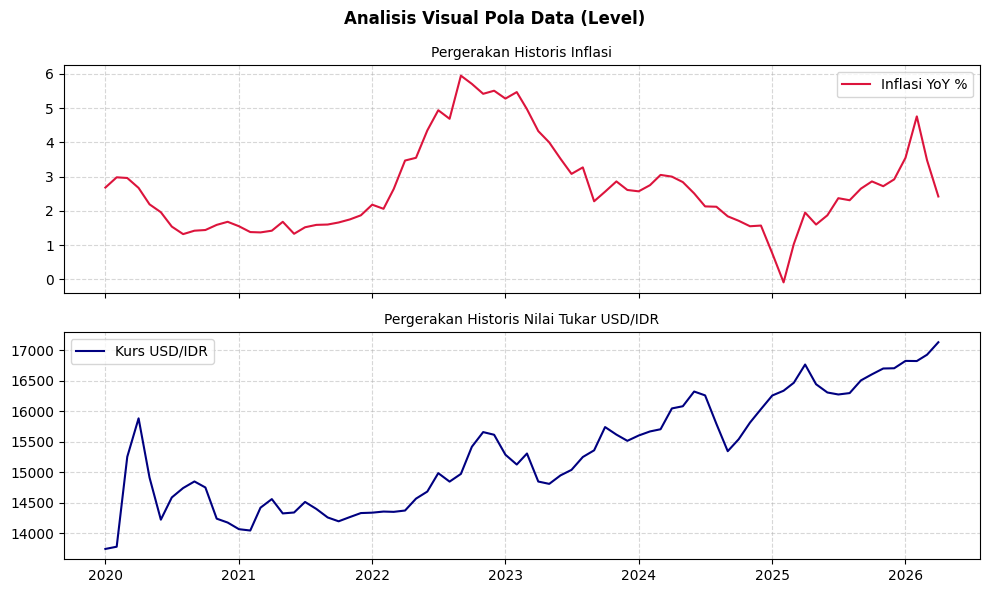

[INFO] Grafik berhasil dirender. Gunakan visualisasi ini untuk justifikasi Bab 4 Anda.

 TAHAP 4 & 5: ADAPTIVE STATIONARITY FILTER (JOINT MATRIX) 
[MATRIKS VERIFIKASI SILANG P-VALUE LENGKAP]
           Variabel ADF_Lvl_p KPSS_Lvl_p ADF_Diff_p KPSS_Diff_p
      inflasi yoy %    0.0595     0.1000     0.0045      0.1000
nilai tukar usd idr    0.9740     0.0100     0.0000      0.1000

[EVALUASI BERDASARKAN STRATEGI FILTER: ADF_ONLY]:
  - Var 'inflasi yoy %' -> Non-Stasioner Level: True | Stasioner Diff: True -> Lolos I(1): True
  - Var 'nilai tukar usd idr' -> Non-Stasioner Level: True | Stasioner Diff: True -> Lolos I(1): True

 TAHAP 6: SELEKSI LAG & SENSITIVITAS RANK KOINTEGRASI JOHANSEN 
   - Optimal Lag VAR (Level Data) berdasarkan AIC: 12
   - Ordo Lag Diferensiasi VECM (k_ar_diff = p - 1): 11

[TABEL EVALUASI SENSITIVITAS DETERMINISTIC TERM JOHANSEN]
  - Spesifikasi det_order = -1 -> Menghasilkan Rank Kointegrasi (r) = 1
  - Spesifikasi det_order =  0 -> Menghasilkan Rank Kointegras

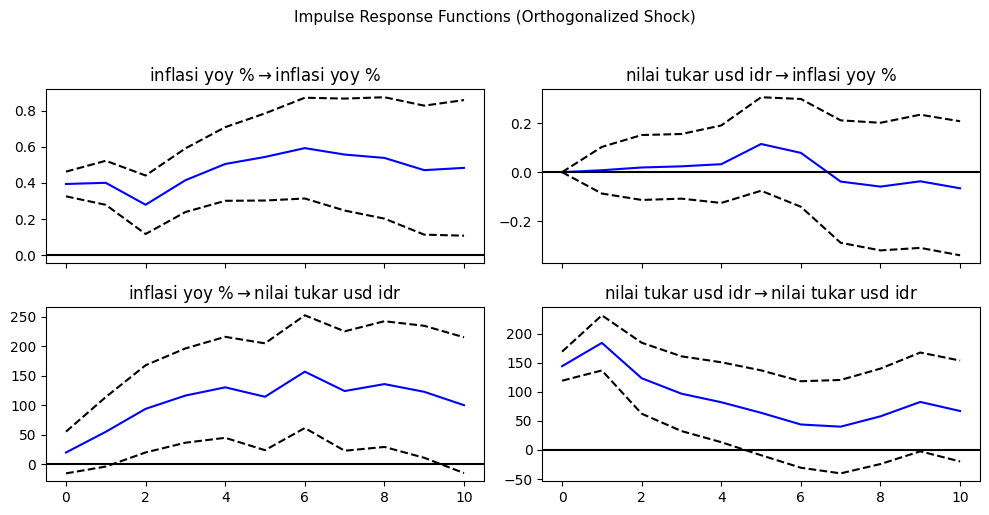

   - Catatan Sampingan FEVD: Tidak dapat memproses visualisasi grafis ('VECMResults' object has no attribute 'fevd').

 TAHAP 11: EVALUASI OUT-OF-SAMPLE (FIXED TANGGAL ORIGIN FORECAST) 
  - Rentang Data Train: 2020-01 s.d. 2023-12 (48 Obs)
  - Rentang Data Test : 2024-02 s.d. 2026-04 (27 Obs)

[TABEL METRIKS AKURASI OUT-OF-SAMPLE]
           Variabel         MAE        RMSE   MAPE
      inflasi yoy %    2.447776    3.036891    N/A
nilai tukar usd idr 2161.543594 2347.659127 13.16%
-------------------------------------------------------------------------------------


In [7]:
# =====================================================================
# PROGRAM UTAMA: ANALISIS RUNTUN WAKTU EKONOMETRIKA MULTIVARIAT (REVISED V13)
# FULL PIPELINE BLUEPRINT: TAHAP 1 SAMPAI TAHAP 11 (COMPLETE & SEAMLESS)
# =====================================================================

import io
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# Library Evaluasi & Diagnostik
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error
from statsmodels.stats.diagnostic import het_arch

# Modul Statistik & Ekonometrika
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.vector_ar.vecm import VECM, select_coint_rank
from statsmodels.tsa.vector_ar.var_model import VAR

# Menonaktifkan notifikasi kaku dari pustaka ekonometrika
warnings.filterwarnings('ignore')

# =====================================================================
# CONFIGURATION PANEL (KONTROL PENELITI - SESUAIKAN DENGAN NARRATIVE)
# =====================================================================
SPESIFIKASI_TREN = {
    'inflasi yoy %': 'c',        # 'c' = constant, 'ct' = constant + trend
    'nilai tukar usd idr': 'c'
}

STRATEGI_FILTER = "ADF_ONLY"

# Solusi Emas berdasarkan data riil Anda (det_order=-1 menghasilkan Rank r=1)
DET_ORDER_JOHANSEN_FINAL = -1

# Panel Intervensi Manual (Gunakan jika diperlukan)
MANUAL_LAG_LEVEL = None       # Pilihan: None (otomatis AIC) atau isi angka integer langsung
MANUAL_COINT_RANK = None      # Pilihan: None (otomatis) atau isi angka 1 untuk memaksa sistem

# Penentuan Origin Forecast berbasis Tanggal Kalender
TANGGAL_CUTOFF_TRAIN = '2023-12-31'

# Orientasi Output Program: "AKADEMIK_STRIKT" atau "FORECAST_PIPELINE"
MODE_PENELITIAN = "AKADEMIK_STRIKT"


# =====================================================================
# • TAHAP 1: INISIALISASI & PROSES UNGGAH DATASET PENELITIAN
# =====================================================================
print("==================================================================")
print(" TAHAP 1: PROSES UNGGAH DATASET PENELITIAN                        ")
print("==================================================================")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
if file_name.endswith('.xlsx') or file_name.endswith('.xls'):
    excel_file = pd.ExcelFile(io.BytesIO(uploaded[file_name]))
    if 'Dataset Modeling' in excel_file.sheet_names:
        df = pd.read_excel(excel_file, sheet_name='Dataset Modeling')
    elif 'Dataset_Final' in excel_file.sheet_names:
        df = pd.read_excel(excel_file, sheet_name='Dataset_Final')
    else:
        df = pd.read_excel(excel_file, sheet_name=0)
else:
    df = pd.read_csv(io.BytesIO(uploaded[file_name]))


# =====================================================================
# • TAHAP 2: PREPROCESSING & TRANSFORMASI STRUKTUR RUNTUN WAKTU
# =====================================================================
print("\n" + "="*85)
print(" TAHAP 2: PREPROCESSING & TRANSFORMASI STRUKTUR RUNTUN WAKTU ")
print("="*85)

df.columns = df.columns.str.strip().str.lower()
tanggal_cols = [c for c in df.columns if 'tanggal' in c or 'date' in c]
inflasi_cols = [c for c in df.columns if 'inflasi' in c or 'inflation' in c]
kurs_cols = [c for c in df.columns if 'kurs' in c or 'tukar' in c or 'exchange' in c or 'rate' in c]

if not (tanggal_cols and inflasi_cols and kurs_cols):
    raise ValueError("[CRITICAL ERROR] Struktur kolom tidak memenuhi prasyarat.")

kolom_tanggal, kolom_inflasi, kolom_kurs = tanggal_cols[0], inflasi_cols[0], kurs_cols[0]
df[kolom_tanggal] = pd.to_datetime(df[kolom_tanggal])
df.set_index(kolom_tanggal, inplace=True)
df.sort_index(inplace=True)

df[kolom_inflasi] = pd.to_numeric(df[kolom_inflasi], errors='coerce')
df[kolom_kurs] = pd.to_numeric(df[kolom_kurs], errors='coerce')
df.dropna(subset=[kolom_inflasi, kolom_kurs], inplace=True)

data_model = df[[kolom_inflasi, kolom_kurs]]
data_model.columns = ['inflasi yoy %', 'nilai tukar usd idr']
n_obs = len(data_model)
max_lags_calc = min(12, max(2, n_obs // 6))

print(f"  - Total Observasi Valid Terdeteksi: {n_obs}")
print(f"  - Periode Data Awal : {data_model.index.min().strftime('%Y-%m-%d')}")
print(f"  - Periode Data Akhir: {data_model.index.max().strftime('%Y-%m-%d')}")


# =====================================================================
# • TAHAP 3: VISUALISASI TREN & INSPEKSI GRAFIK AWAL
# =====================================================================
print("\n" + "="*85)
print(" TAHAP 3: VISUALISASI TREN & INSPEKSI GRAFIK AWAL ")
print("="*85)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(data_model['inflasi yoy %'], color='crimson', lw=1.5, label='Inflasi YoY %')
axes[0].set_title("Pergerakan Historis Inflasi", fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

axes[1].plot(data_model['nilai tukar usd idr'], color='navy', lw=1.5, label='Kurs USD/IDR')
axes[1].set_title("Pergerakan Historis Nilai Tukar USD/IDR", fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

plt.suptitle("Analisis Visual Pola Data (Level)", fontsize=12, weight='bold', y=0.98)
plt.tight_layout()
plt.show()
print("[INFO] Grafik berhasil dirender. Gunakan visualisasi ini untuk justifikasi Bab 4 Anda.")


# =====================================================================
# • TAHAP 4 & 5: ADAPTIVE STATIONARITY FILTER (ADF VS KPSS MATRIX)
# =====================================================================
print("\n" + "="*85)
print(" TAHAP 4 & 5: ADAPTIVE STATIONARITY FILTER (JOINT MATRIX) ")
print("="*85)

data_diff = data_model.diff().dropna()
joint_matrix = []

for col in data_model.columns:
    spec = SPESIFIKASI_TREN[col]
    kpss_spec = 'c' if spec == 'c' else 'ct'

    adf_l = adfuller(data_model[col], regression=spec, autolag='AIC')
    kpss_l = kpss(data_model[col], regression=kpss_spec, nlags='auto')
    adf_d = adfuller(data_diff[col], regression='c', autolag='AIC')
    kpss_d = kpss(data_diff[col], regression='c', nlags='auto')

    joint_matrix.append({
        'Variabel': col,
        'ADF_Lvl_p': adf_l[1], 'KPSS_Lvl_p': kpss_l[1],
        'ADF_Diff_p': adf_d[1], 'KPSS_Diff_p': kpss_d[1]
    })

df_joint = pd.DataFrame(joint_matrix)
print("[MATRIKS VERIFIKASI SILANG P-VALUE LENGKAP]")
print(df_joint.to_string(index=False, formatters={
    'ADF_Lvl_p': '{:,.4f}'.format, 'KPSS_Lvl_p': '{:,.4f}'.format,
    'ADF_Diff_p': '{:,.4f}'.format, 'KPSS_Diff_p': '{:,.4f}'.format
}))

is_pure_I1 = True
print(f"\n[EVALUASI BERDASARKAN STRATEGI FILTER: {STRATEGI_FILTER}]:")
for col in data_model.columns:
    row = df_joint[df_joint['Variabel'] == col].iloc[0]

    if STRATEGI_FILTER == "STRIKT_JOINT":
        lvl_is_non_stationary = (row['ADF_Lvl_p'] >= 0.05) and (row['KPSS_Lvl_p'] < 0.05)
        diff_is_stationary = (row['ADF_Diff_p'] < 0.05) and (row['KPSS_Diff_p'] >= 0.05)
    else:  # ADF_ONLY
        lvl_is_non_stationary = (row['ADF_Lvl_p'] >= 0.05)
        diff_is_stationary = (row['ADF_Diff_p'] < 0.05)

    var_confirmed_I1 = lvl_is_non_stationary and diff_is_stationary
    print(f"  - Var '{col}' -> Non-Stasioner Level: {lvl_is_non_stationary} | Stasioner Diff: {diff_is_stationary} -> Lolos I(1): {var_confirmed_I1}")
    if not var_confirmed_I1:
        is_pure_I1 = False

use_vecm = True
if not is_pure_I1:
    print("\n>> [PERINGATAN METODOLOGI] Karakteristik kointegrasi murni I(1) gagal terpenuhi.")
    if MODE_PENELITIAN == "AKADEMIK_STRIKT":
        sys.exit("[STOP] Program dihentikan demi integritas metodologi penelitian Anda.")
    else:
        print(">> PIVOT SYSTEM: Mengalihkan otomatis ke Jalur Fallback VAR(Δ).")
        use_vecm = False


# =====================================================================
# • TAHAP 6: SELEKSI LAG & SENSITIVITAS RANK KOINTEGRASI JOHANSEN
# =====================================================================
print("\n" + "="*85)
print(" TAHAP 6: SELEKSI LAG & SENSITIVITAS RANK KOINTEGRASI JOHANSEN ")
print("="*85)

if MANUAL_LAG_LEVEL is not None:
    p_level = MANUAL_LAG_LEVEL
    print(f"   - [MANUAL INTERVENSI] Lag VAR (Level Data) dipaksa ke: {p_level}")
else:
    from statsmodels.tsa.vector_ar.vecm import select_order as vecm_select_order
    lag_order_levels = vecm_select_order(data_model, maxlags=max_lags_calc, deterministic='ci')
    p_level = int(lag_order_levels.aic) if lag_order_levels.aic is not None else 1
    if p_level == 0: p_level = 1
    print(f"   - Optimal Lag VAR (Level Data) berdasarkan AIC: {p_level}")

k_ar_diff = p_level - 1
print(f"   - Ordo Lag Diferensiasi VECM (k_ar_diff = p - 1): {k_ar_diff}")

print("\n[TABEL EVALUASI SENSITIVITAS DETERMINISTIC TERM JOHANSEN]")
for d_order in [-1, 0, 1]:
    ct_test = select_coint_rank(data_model, det_order=d_order, k_ar_diff=k_ar_diff, method='trace', signif=0.05)
    print(f"  - Spesifikasi det_order = {d_order:2d} -> Menghasilkan Rank Kointegrasi (r) = {ct_test.rank}")

if MANUAL_COINT_RANK is not None:
    coint_rank = MANUAL_COINT_RANK
    print(f"\n>> [MANUAL INTERVENSI] Rank Kointegrasi dipaksa ke: r = {coint_rank}")
else:
    coint_test_final = select_coint_rank(data_model, det_order=DET_ORDER_JOHANSEN_FINAL, k_ar_diff=k_ar_diff, method='trace', signif=0.05)
    coint_rank = coint_test_final.rank
    print(f"\n>> Rank Kointegrasi Terpilih (det_order={DET_ORDER_JOHANSEN_FINAL}): r = {coint_rank}")

if use_vecm and coint_rank == 0:
    print("\n>> [PERINGATAN] Rank = 0. Tidak ditemukan hubungan jangka panjang.")
    if MODE_PENELITIAN == "AKADEMIK_STRIKT":
        sys.exit("[STOP] Program dihentikan. Kointegrasi r=0 menolak dasar teori VECM.")
    else:
        print(">> PIVOT SYSTEM: Mengalihkan otomatis ke Jalur Fallback VAR(Δ).")
        use_vecm = False


# =====================================================================
# • TAHAP 7: ESTIMASI MODEL FINAL (VECM ATAU FALLBACK VAR)
# =====================================================================
print("\n" + "="*85)
print(" TAHAP 7: ESTIMASI MODEL STATISTIK FINAL ")
print("="*85)

if use_vecm:
    print(">>> ESTIMASI MODEL VECM FINAL BERHASIL:")
    det_string = 'nc' if DET_ORDER_JOHANSEN_FINAL == -1 else 'ci'
    model_final_fit = VECM(data_model, k_ar_diff=k_ar_diff, coint_rank=coint_rank, deterministic=det_string).fit()
    print(model_final_fit.summary())
else:
    print(">>> ESTIMASI JALUR FALLBACK DEDICATED VAR(Δ) BERHASIL:")
    from statsmodels.tsa.vector_ar.var_model import select_order as var_select_order
    p_diff = int(var_select_order(data_diff, maxlags=max_lags_calc, deterministic='c').aic)
    p_diff = 1 if p_diff == 0 else p_diff
    model_final_fit = VAR(data_diff).fit(maxlags=p_diff, ic=None)
    print(model_final_fit.summary())


# =====================================================================
# • TAHAP 8 & 9: DIAGNOSTIK RESIDUAL & VERIFIKASI STABILITAS AKAR EIGEN
# =====================================================================
print("\n" + "="*85)
print(" TAHAP 8 & 9: DIAGNOSTIK RESIDUAL & VERIFIKASI STABILITAS MATRIKS AKAR ")
print("="*85)

if use_vecm:
    try:
        print(f"   - Portmanteau Autokorelasi p-value: {model_final_fit.test_whiteness(nlags=k_ar_diff+4).pval:.4f}")
        print(f"   - Jarque-Bera Normalitas p-value: {model_final_fit.test_normality().pval:.4f}")
    except: print("   - Gagal memproses beberapa uji diagnostik standar karena keterbatasan derajat bebas.")

    nlags_arch = min(12, max(1, len(model_final_fit.resid) // 5))
    for i, col in enumerate(data_model.columns):
        arch_t = het_arch(model_final_fit.resid[:, i], nlags=nlags_arch)
        print(f"   - ARCH-LM Heteroskedastisitas [{col}] p-value: {arch_t[1]:.4f}")

    atol_eigen = 1e-3
    K_v = data_model.shape[1]
    var_rep_coefs = model_final_fit.var_rep
    p_l, _, _ = var_rep_coefs.shape
    comp_matrix = np.zeros((K_v * p_l, K_v * p_l))
    for j in range(p_l): comp_matrix[:K_v, j*K_v:(j+1)*K_v] = var_rep_coefs[j]
    if p_l > 1: comp_matrix[K_v:, :K_v*(p_l-1)] = np.eye(K_v * (p_l - 1))

    abs_eigvals = np.abs(np.linalg.eigvals(comp_matrix))
    espektur_unit_root = K_v - coint_rank
    akar_unit_aktual = np.sum(np.isclose(abs_eigvals, 1.0, atol=atol_eigen))
    akar_eksplosif = np.sum(abs_eigvals > (1.0 + atol_eigen))

    print(f"   - Modulus Seluruh Nilai Eigen VECM: {np.round(abs_eigvals, 4)}")
    print(f"   - Jumlah Unit Root Terdeteksi (atol={atol_eigen}): {akar_unit_aktual} (Ekspektasi K - r = {espektur_unit_root})")

    if akar_eksplosif > 0: print("   - [KESIMPULAN VALIDITAS]: PERINGATAN! Sistem memiliki akar eksplosif.")
    elif akar_unit_aktual != espektur_unit_root: print("   - [KESIMPULAN VALIDITAS]: COINTEGRATION STRUCTURE MISSPECIFIED!")
    else: print("   - [KESIMPULAN VALIDITAS]: MODEL VECM SEPENUHNYA STABIL DAN METODOLOGIS.")
else:
    abs_roots = np.abs(model_final_fit.roots)
    print(f"   - Modulus Akar Polinomial VAR(Δ): {np.round(abs_roots, 4)}")
    if np.all(abs_roots > (1.0 + 1e-3)): print("   - [KESIMPULAN VALIDITAS]: MODEL VAR(Δ) MEMENUHI SYARAT STASIONERITAS ABSOLUT.")
    else: print("   - [KESIMPULAN VALIDITAS]: PERINGATAN! Sistem VAR tidak stabil.")


# =====================================================================
# • TAHAP 10: SHOCK ANALYSIS DYNAMICS (IRF & FEVD)
# =====================================================================
print("\n" + "="*85)
print(" TAHAP 10: ANALISIS DINAMIKA SHOCK STRUKTURAL (IRF & FEVD) ")
print("="*85)

periods_analysis = 10
irf_obj = model_final_fit.irf(periods=periods_analysis)
fig_irf = irf_obj.plot(orth=True, figsize=(10, 5))
plt.suptitle("Impulse Response Functions (Orthogonalized Shock)", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

try:
    fevd_obj = model_final_fit.fevd(periods=periods_analysis)
    print("\n[TABEL FORECAST ERROR VARIANCE DECOMPOSITION (FEVD)]")
    print(fevd_obj.summary())

    fig_fevd = fevd_obj.plot(figsize=(10, 5))
    plt.suptitle("Variance Decomposition Analysis", fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"   - Catatan Sampingan FEVD: Tidak dapat memproses visualisasi grafis ({str(e)}).")


# =====================================================================
# • TAHAP 11: EVALUASI AKURASI OUT-OF-SAMPLE BERBASIS TANGGAL KALENDER
# =====================================================================
print("\n" + "="*85)
print(" TAHAP 11: EVALUASI OUT-OF-SAMPLE (FIXED TANGGAL ORIGIN FORECAST) ")
print("="*85)

train_data = data_model.loc[:TANGGAL_CUTOFF_TRAIN]
test_data = data_model.loc[TANGGAL_CUTOFF_TRAIN:].iloc[1:]

if len(test_data) == 0:
    print("[ALERT] Tanggal cutoff train terlalu besar, tidak menyisakan data untuk test!")
else:
    print(f"  - Rentang Data Train: {train_data.index.min().strftime('%Y-%m')} s.d. {train_data.index.max().strftime('%Y-%m')} ({len(train_data)} Obs)")
    print(f"  - Rentang Data Test : {test_data.index.min().strftime('%Y-%m')} s.d. {test_data.index.max().strftime('%Y-%m')} ({len(test_data)} Obs)")

    if use_vecm:
        det_string = 'nc' if DET_ORDER_JOHANSEN_FINAL == -1 else 'ci'
        model_train = VECM(train_data, k_ar_diff=k_ar_diff, coint_rank=coint_rank, deterministic=det_string).fit()
        predictions_raw = model_train.predict(steps=len(test_data))
    else:
        train_diff = train_data.diff().dropna()
        model_train = VAR(train_diff).fit(maxlags=p_diff, ic=None)
        pred_diff = model_train.forecast(train_diff.values, steps=len(test_data))

        predictions_raw = []
        last_level = train_data.iloc[-1].values
        for step in range(len(test_data)):
            last_level = last_level + pred_diff[step]
            predictions_raw.append(last_level)
        predictions_raw = np.array(predictions_raw)

    metrics_summary = []
    for i, col in enumerate(data_model.columns):
        mae = mean_absolute_error(test_data.iloc[:, i], predictions_raw[:, i])
        rmse = np.sqrt(mean_squared_error(test_data.iloc[:, i], predictions_raw[:, i]))
        if col == 'inflasi yoy %' and (test_data.iloc[:, i].abs() < 0.1).any(): mape_str = "N/A"
        else:
            mape_raw = mean_absolute_percentage_error(test_data.iloc[:, i], predictions_raw[:, i]) * 100
            mape_str = f"{mape_raw:.2f}%"
        metrics_summary.append({'Variabel': col, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape_str})

    df_metrics = pd.DataFrame(metrics_summary)
    print("\n[TABEL METRIKS AKURASI OUT-OF-SAMPLE]")
    print(df_metrics[['Variabel', 'MAE', 'RMSE', 'MAPE']].to_string(index=False))
print("-" * 85)